# HW4_Clustering

In [1]:
# Import packages
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [11]:
# Import the data
retail = pd.read_csv('/Users/zoerivers/Documents/AAE 625/AAE625_2026/RetailData.csv', sep='|')
retail.head()
retail.columns

Index(['Unnamed: 0', 'STORE_ID', 'PRICE', 'QUANTITY', 'REVENUE',
       'AVERAGE_LENGTH_OF_RESIDENCE', 'PERCENTAGE_OF_RENTERS',
       'PERCENT_HAVING_CHILDREN', 'AVERAGE_INCOME', 'AVERAGE_AGE_IN_YEARS',
       'PERCENT_SPEAKING_SPANISH'],
      dtype='object')

In [12]:
# Create log variables
retail['ln_Q'] = np.log(retail['QUANTITY'])
retail['ln_P'] = np.log(retail['PRICE'])
retail['ln_R'] = np.log(retail['PERCENTAGE_OF_RENTERS'])
retail['ln_C'] = np.log(retail['PERCENT_HAVING_CHILDREN'])
retail['ln_I'] = np.log(retail['AVERAGE_INCOME'])
retail['ln_S'] = np.log(retail['PERCENT_SPEAKING_SPANISH'])

# Estimate log_log model
X = retail[['ln_P','ln_R','ln_C','ln_I','ln_S']]
X = sm.add_constant(X)

y = retail['ln_Q']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   ln_Q   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     113.1
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           1.47e-65
Time:                        20:03:59   Log-Likelihood:                -30.391
No. Observations:                 291   AIC:                             72.78
Df Residuals:                     285   BIC:                             94.82
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7401      0.706     12.373      0.0

# (a)

In [19]:
# Construct two variables
retail['PRICE_DELTA'] = retail['PRICE'] - retail['PRICE'].mean()

retail['ln_Q_hat'] = model.predict(X)
retail['Q_hat'] = np.exp(retail['ln_Q_hat'])
retail['R_QUANTITY'] = retail['QUANTITY'] - retail['Q_hat']

# Standardize PRICE_DELTA and R_QUANTITY
from sklearn.preprocessing import StandardScaler
features = retail[['PRICE_DELTA', 'R_QUANTITY']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Fit a K-means model(K=5)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
retail['cluster'] = kmeans.fit_predict(scaled_features)

# Output
print("Cluster centers (standardized scale):")
print(kmeans.cluster_centers_)

print("\nNumber of iterations to convergence:")
print(kmeans.n_iter_)

centers_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['PRICE_DELTA_scaled', 'R_QUANTITY_scaled']
)


centers_df.index.name = 'Cluster'

centers_df

Cluster centers (standardized scale):
[[-1.50999433 -0.42802311]
 [ 0.1641006   0.2081588 ]
 [ 0.06437096 -1.34762709]
 [ 1.74172074 -0.53734294]
 [-0.10691312  1.59464397]]

Number of iterations to convergence:
10


,PRICE_DELTA_scaled,R_QUANTITY_scaled
Cluster,,
0,-1.509994,-0.428023
1,0.164101,0.208159
2,0.064371,-1.347627
3,1.741721,-0.537343
4,-0.106913,1.594644


I standardized PRICE_DELTA and R_QUANTITY using StandardScaler and fit a K-means model with K=5, random_state=42, and n_init=10. 
The table above reports the cluster centers in standardized units. The algorithm converged in 10 iterations.

# (b)

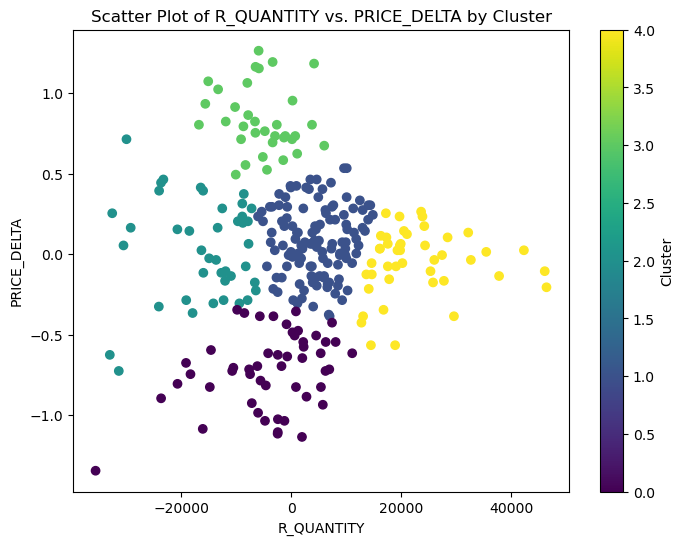

In [20]:
# Create a scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    retail['R_QUANTITY'],
    retail['PRICE_DELTA'],
    c=retail['cluster']
)

plt.xlabel('R_QUANTITY')
plt.ylabel('PRICE_DELTA')
plt.title('Scatter Plot of R_QUANTITY vs. PRICE_DELTA by Cluster')
plt.colorbar(scatter, label='Cluster')
plt.show()

# (c)

In [21]:
# Report
cluster_summary = retail.groupby('cluster').agg(
    mean_PRICE_DELTA=('PRICE_DELTA', 'mean'),
    mean_R_QUANTITY=('R_QUANTITY', 'mean'),
    n_stores=('cluster', 'size')
)

cluster_summary.round(2)

,mean_PRICE_DELTA,mean_R_QUANTITY,n_stores
cluster,,,
0,-0.72,-3881.83,51
1,0.08,4535.74,121
2,0.03,-16049.48,41
3,0.83,-5328.29,34
4,-0.05,22880.87,44


* The table reports the mean PRICE_DELTA and mean R_QUANTITY for each cluster. Overall, the clusters show clear differences in pricing and sales performance across stores.
* Cluster 0 is low-priced and under-performing.
* Cluster 1 is slightly high-priced and over-performing.
* Cluster 2 is slightly high-priced but under-performing.
* Cluster 3 is high-priced and under-performing.
* Cluster 4 is slightly low-priced and strongly over-performing.